# Phase 1 — Exploratory Data Analysis
Rossmann Store Sales

In [1]:
%pip install pandas numpy matplotlib seaborn --quiet

""" pyenv install 3.12.8
pyenv virtualenv 3.12.8 rossmann-store
pyenv local rossmann-store          # sets .python-version automatically
pyenv activate rossmann-store """

Note: you may need to restart the kernel to use updated packages.


' pyenv install 3.12.8\npyenv virtualenv 3.12.8 rossmann-store\npyenv local rossmann-store          # sets .python-version automatically\npyenv activate rossmann-store '

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)

DATA = './'

## 1.1 Data Loading & Shape

In [5]:
train = pd.read_csv(DATA + 'train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv(DATA + 'store.csv')
test  = pd.read_csv(DATA + 'test.csv',  parse_dates=['Date'], low_memory=False)

print('train:', train.shape)
print('store:', store.shape)
print('test: ', test.shape)

train: (1017209, 9)
store: (1115, 10)
test:  (41088, 8)


In [8]:
train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [9]:
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [10]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [11]:
# Merge store metadata into train and test
train = train.merge(store, on='Store', how='left')
test  = test.merge(store,  on='Store', how='left')

print('train after merge:', train.shape)
print('test  after merge:', test.shape)

train after merge: (1017209, 18)
test  after merge: (41088, 17)


In [12]:
train.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                            str
SchoolHoliday                         int64
StoreType                               str
Assortment                              str
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                           str
dtype: object

## 1.2 Missing Value Audit

In [13]:
def missing_report(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': miss, 'pct': pct})
    print(f'\n--- {name} ---')
    print(report if len(report) else 'No missing values.')
    return report

_ = missing_report(train, 'train (merged)')
_ = missing_report(test,  'test  (merged)')


--- train (merged) ---
                           missing    pct
Promo2SinceWeek             508031  49.94
Promo2SinceYear             508031  49.94
PromoInterval               508031  49.94
CompetitionOpenSinceMonth   323348  31.79
CompetitionOpenSinceYear    323348  31.79
CompetitionDistance           2642   0.26

--- test  (merged) ---
                           missing    pct
Promo2SinceWeek              17232  41.94
Promo2SinceYear              17232  41.94
PromoInterval                17232  41.94
CompetitionOpenSinceMonth    15216  37.03
CompetitionOpenSinceYear     15216  37.03
CompetitionDistance             96   0.23
Open                            11   0.03


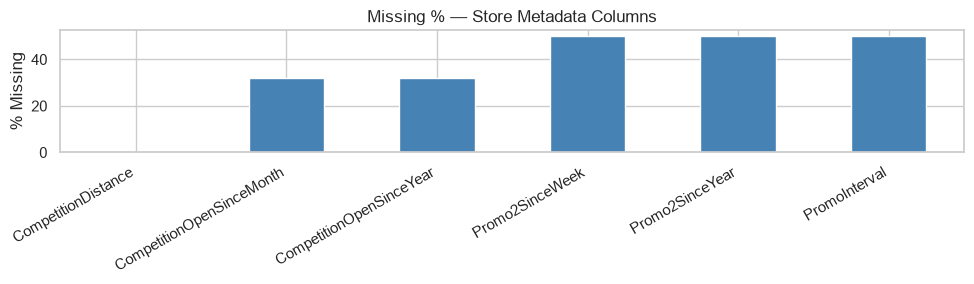

In [15]:
# Visualise missing pattern in store columns
store_cols = ['CompetitionDistance','CompetitionOpenSinceMonth','CompetitionOpenSinceYear',
              'Promo2SinceWeek','Promo2SinceYear','PromoInterval']

fig, ax = plt.subplots(figsize=(10, 3))
miss_pct = train[store_cols].isnull().mean() * 100
miss_pct.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Missing % — Store Metadata Columns')
ax.set_ylabel('% Missing')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 1.3 Target Distribution

In [16]:
# How many rows have Open=0?
closed = train[train['Open'] == 0]
print(f'Closed rows: {len(closed):,} ({len(closed)/len(train)*100:.1f}%)')
print(f'Sales when closed — min: {closed.Sales.min()}, max: {closed.Sales.max()}, mean: {closed.Sales.mean():.2f}')

Closed rows: 172,817 (17.0%)
Sales when closed — min: 0, max: 0, mean: 0.00


In [18]:
# Work only on open days from here
train_open = train[train['Open'] == 1].copy()
print(f'Open rows: {len(train_open)}, ({len(train_open)/len(train)*100:.1f}%)')

Open rows: 844392, (83.0%)


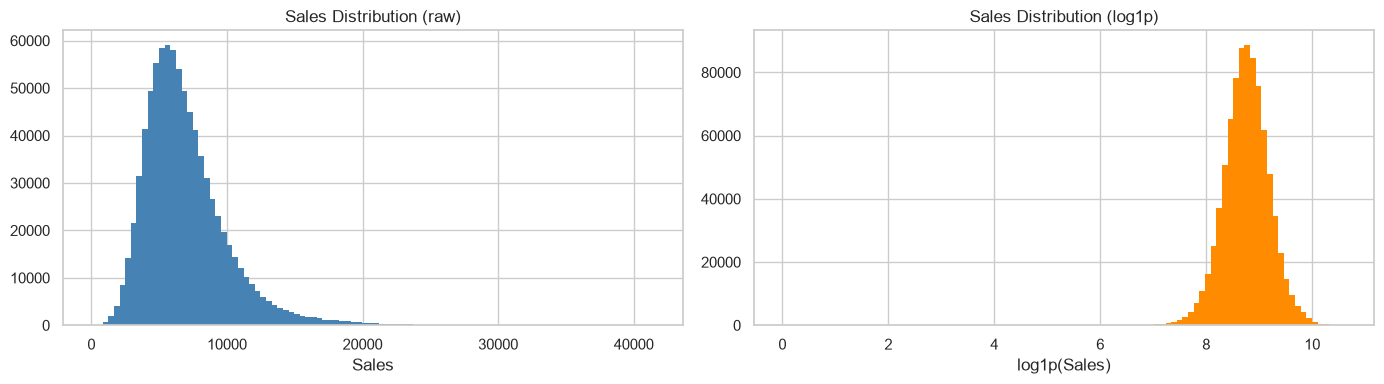

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw sales
axes[0].hist(train_open['Sales'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Sales Distribution (raw)')
axes[0].set_xlabel('Sales')

# Log-transformed
axes[1].hist(np.log1p(train_open['Sales']), bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Sales Distribution (log1p)')
axes[1].set_xlabel('log1p(Sales)')

plt.tight_layout()
plt.show()

print(train_open['Sales'].describe())

**Above sales data is strongly right-skewed in raw form**, and `log1p` was used to make that distribution more compact and closer to symmetric.

In the **left plot (raw sales)**:
- Most sales values are concentrated in the lower range.
- A small number of observations have very large sales.
- This creates a **long right tail**, meaning the distribution is **positively skewed**.

In the **right plot (`log1p(sales)`)**:
- Large sales values are compressed more than small ones.
- The shape becomes more balanced and less skewed.
- Patterns are easier to see, and extreme values stop dominating the scale.

**Why `log1p` specifically?**  
`log1p(x)` means:

```python
log1p(x) = log(1 + x)
```

It is used instead of plain `log(x)` because:
- `log(0)` is undefined
- but `log1p(0) = log(1) = 0`

So if sales can be zero, `log1p` is safe.

**Significance of using it:**
1. **Reduces skewness** — makes the data closer to normal.
2. **Controls outliers** — very large sales values have less influence.
3. **Stabilizes variance** — useful when spread increases with magnitude.
4. **Helps many models** — especially linear regression, ARIMA-like models, and methods that work better with more symmetric data.
5. **Improves visualization** — the distribution becomes easier to interpret.

A simple intuition:
- Raw scale cares about **absolute differences**
- Log scale cares more about **relative/percentage differences**

For example, the jump from 1000 to 2000 is treated similarly to 10000 to 20000 on a log scale, because both are roughly a **2x increase**.

So, **you took `log1p` because sales are heavily right-skewed, and this transform makes the distribution more model-friendly and interpretable**.

## 1.4 Time-based Patterns

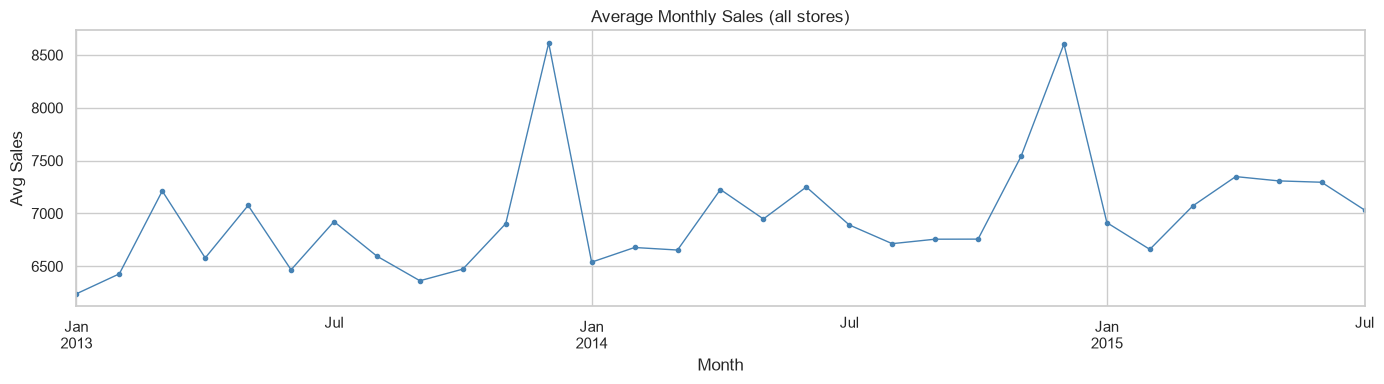

In [20]:
# Monthly average sales
monthly = train_open.groupby(train_open['Date'].dt.to_period('M'))['Sales'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color='steelblue', marker='o', markersize=3, linewidth=1)
ax.set_title('Average Monthly Sales (all stores)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Sales')
plt.tight_layout()
plt.show()

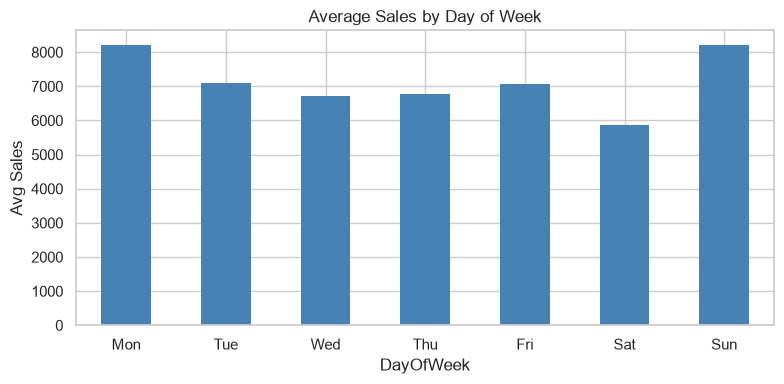

In [21]:
# Sales by DayOfWeek
dow_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
dow_sales = train_open.groupby('DayOfWeek')['Sales'].mean().rename(index=dow_map)

fig, ax = plt.subplots(figsize=(8, 4))
dow_sales.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Average Sales by Day of Week')
ax.set_ylabel('Avg Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

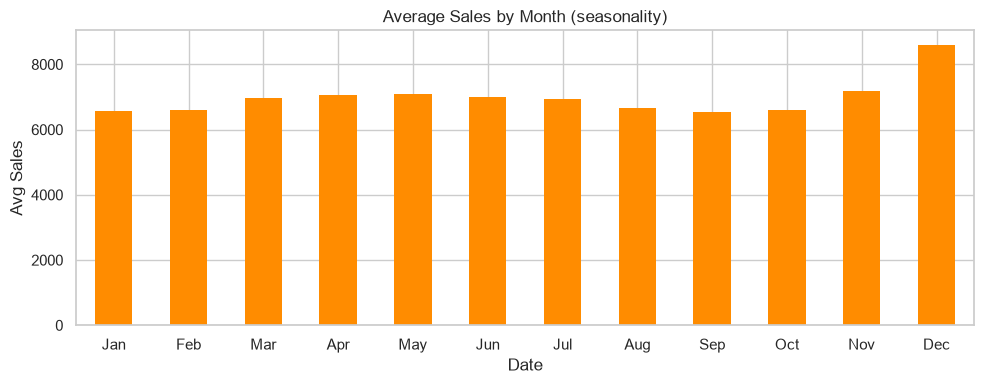

In [22]:
# Sales by Month (seasonality)
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_sales = train_open.groupby(train_open['Date'].dt.month)['Sales'].mean().rename(index=month_map)

fig, ax = plt.subplots(figsize=(10, 4))
month_sales.plot(kind='bar', ax=ax, color='darkorange', edgecolor='none')
ax.set_title('Average Sales by Month (seasonality)')
ax.set_ylabel('Avg Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

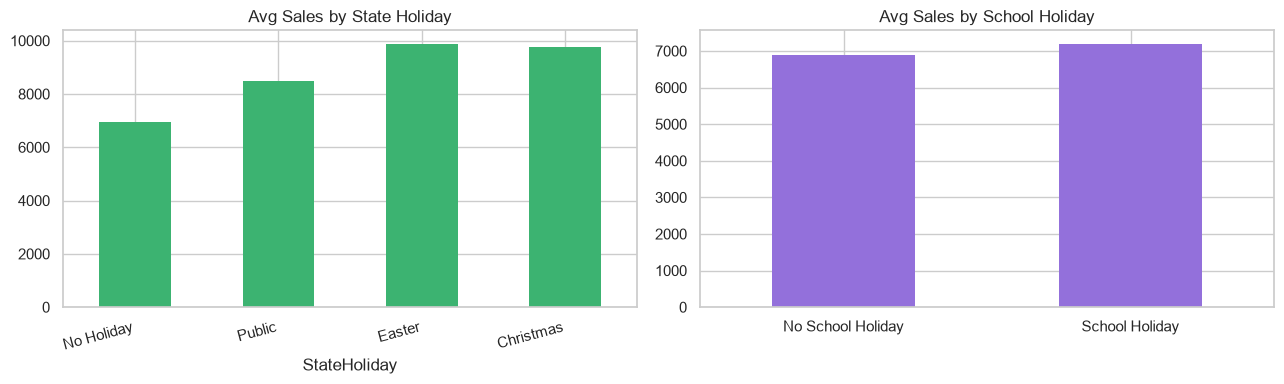

In [23]:
# Holiday effects
holiday_map = {'0': 'No Holiday', 'a': 'Public', 'b': 'Easter', 'c': 'Christmas'}
holiday_sales = train_open.groupby('StateHoliday')['Sales'].mean().rename(index=holiday_map)

school_sales = train_open.groupby('SchoolHoliday')['Sales'].mean()
school_sales.index = ['No School Holiday', 'School Holiday']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
holiday_sales.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='none')
axes[0].set_title('Avg Sales by State Holiday')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

school_sales.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='none')
axes[1].set_title('Avg Sales by School Holiday')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 1.5 Store-level Analysis

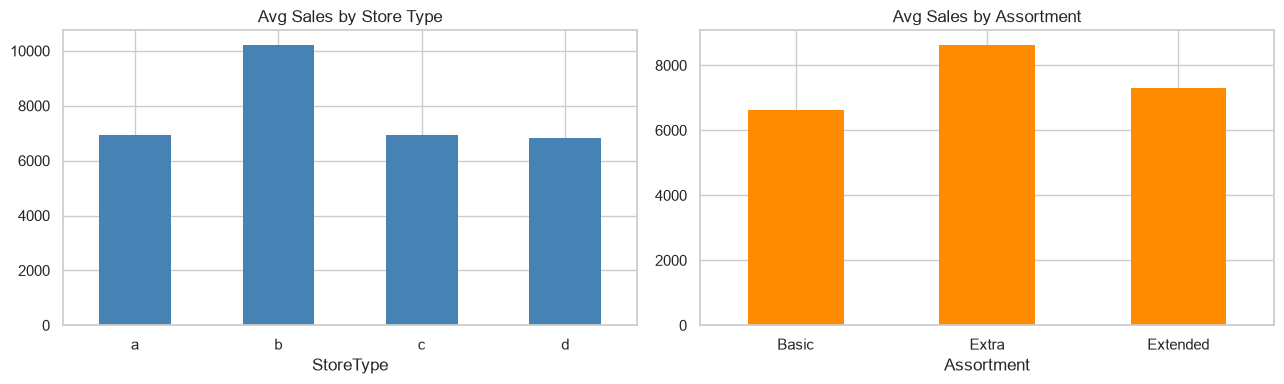

In [24]:
# Sales by StoreType
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

type_sales = train_open.groupby('StoreType')['Sales'].mean()
type_sales.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Avg Sales by Store Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Sales by Assortment
assort_map = {'a': 'Basic', 'b': 'Extra', 'c': 'Extended'}
assort_sales = train_open.groupby('Assortment')['Sales'].mean().rename(index=assort_map)
assort_sales.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='none')
axes[1].set_title('Avg Sales by Assortment')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

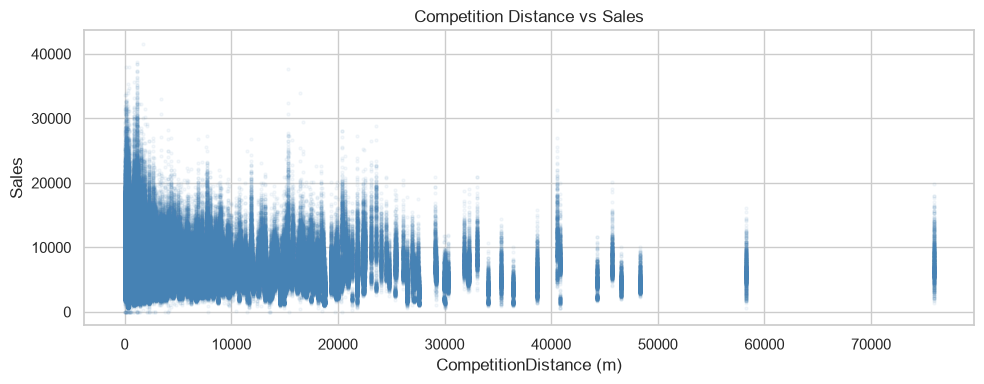

In [25]:
# Competition Distance vs Sales
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(train_open['CompetitionDistance'], train_open['Sales'],
           alpha=0.05, s=5, color='steelblue')
ax.set_title('Competition Distance vs Sales')
ax.set_xlabel('CompetitionDistance (m)')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

In [ ]:
# Competition Distance binned
train_open['CompDist_bin'] = pd.cut(train_open['CompetitionDistance'],
                                     bins=[0, 500, 1000, 2000, 5000, 10000, np.inf],
                                     labels=['<500m','500-1k','1-2k','2-5k','5-10k','>10k'])
comp_sales = train_open.groupby('CompDist_bin')['Sales'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
comp_sales.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='none')
ax.set_title('Avg Sales by Competition Distance Band')
ax.set_ylabel('Avg Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Per-store coefficient of variation (outlier stores)
store_cv = train_open.groupby('Store')['Sales'].agg(['mean','std'])
store_cv['cv'] = store_cv['std'] / store_cv['mean']

fig, ax = plt.subplots(figsize=(12, 3))
ax.hist(store_cv['cv'].dropna(), bins=60, color='mediumpurple', edgecolor='none')
ax.set_title('Per-Store Coefficient of Variation in Sales')
ax.set_xlabel('CV (std/mean)')
plt.tight_layout()
plt.show()

print('Top 10 most volatile stores:')
print(store_cv.nlargest(10, 'cv')[['mean','std','cv']])

## 1.6 Promotion Analysis

In [ ]:
# Promo vs non-promo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for promo_val, label, ax in zip([0, 1], ['No Promo', 'Promo'], axes):
    d = train_open[train_open['Promo'] == promo_val]['Sales']
    ax.hist(d, bins=80, edgecolor='none', alpha=0.8, color='steelblue' if promo_val == 0 else 'darkorange')
    ax.set_title(f'Sales Distribution — {label}')
    ax.set_xlabel('Sales')
    ax.axvline(d.mean(), color='red', linestyle='--', label=f'mean={d.mean():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Promo lift by StoreType
promo_store = train_open.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_store.columns = ['No Promo', 'Promo']
promo_store['Lift %'] = ((promo_store['Promo'] - promo_store['No Promo']) / promo_store['No Promo'] * 100).round(1)

print('Promo Lift by StoreType:')
print(promo_store)

fig, ax = plt.subplots(figsize=(8, 4))
promo_store[['No Promo', 'Promo']].plot(kind='bar', ax=ax, edgecolor='none')
ax.set_title('Avg Sales: Promo vs No Promo by Store Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Promo2 effect
promo2_sales = train_open.groupby('Promo2')['Sales'].mean()
promo2_sales.index = ['No Promo2', 'Promo2']
print('Avg Sales by Promo2 enrollment:', promo2_sales.round(0))

# Promo2 × Assortment
p2_assort = train_open.groupby(['Assortment', 'Promo2'])['Sales'].mean().unstack()
p2_assort.columns = ['No Promo2', 'Promo2']
p2_assort.index = p2_assort.index.map(assort_map)

fig, ax = plt.subplots(figsize=(8, 4))
p2_assort.plot(kind='bar', ax=ax, edgecolor='none')
ax.set_title('Avg Sales: Promo2 vs No Promo2 by Assortment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 1.7 Lag / Carry-over Effects

In [ ]:
# Was store closed the previous day? Does it affect today's sales?
train_sorted = train.sort_values(['Store', 'Date']).copy()
train_sorted['prev_open'] = train_sorted.groupby('Store')['Open'].shift(1)
train_sorted['was_closed_yesterday'] = (train_sorted['prev_open'] == 0).astype(int)

effect = train_sorted[train_sorted['Open'] == 1].groupby('was_closed_yesterday')['Sales'].mean()
effect.index = ['Open yesterday', 'Closed yesterday']
print('Sales carry-over effect:')
print(effect.round(0))

fig, ax = plt.subplots(figsize=(6, 4))
effect.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], edgecolor='none')
ax.set_title('Avg Sales: Was Previous Day Open or Closed?')
ax.set_ylabel('Avg Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Rolling 7-day average sales for a sample store
sample_store = train_sorted[train_sorted['Store'] == 1].copy()
sample_store = sample_store.set_index('Date').sort_index()
sample_store['roll_7'] = sample_store['Sales'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample_store.index, sample_store['Sales'], alpha=0.4, color='steelblue', label='Daily Sales')
ax.plot(sample_store.index, sample_store['roll_7'], color='darkorange', linewidth=2, label='7-day Rolling Mean')
ax.set_title('Store 1 — Daily Sales with 7-day Rolling Mean')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Correlation matrix for numeric columns
num_cols = ['Sales', 'Customers', 'Promo', 'Promo2', 'CompetitionDistance',
            'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
            'Promo2SinceWeek', 'Promo2SinceYear', 'SchoolHoliday']
corr = train_open[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 1.8 Key Findings Summary

In [ ]:
print("""
KEY FINDINGS
============

1. OPEN=0 rows: Sales are always 0 when closed. Drop from training;
   predict 0 directly for test rows where Open=0.

2. TARGET SKEW: Sales is right-skewed. Use log1p transform during
   training and expm1 on final predictions.

3. DAY OF WEEK: Monday & Saturday have highest sales; Sunday is lowest
   (many stores closed).

4. SEASONALITY: December spike (Christmas), dip in January.

5. STORE TYPE B: Significantly higher average sales than a/c/d.

6. PROMO: ~20-30% sales lift on promo days; lift varies by StoreType.

7. CARRY-OVER: Stores closed the previous day see a noticeable sales
   bump (pent-up demand). Add was_closed_yesterday feature.

8. COMPETITION: Closer competition slightly depresses sales, but effect
   diminishes at very close distances (possibly city-centre stores).

9. MISSING DATA: Promo2 fields are ~50% null — mostly because Promo2=0
   stores have no Promo2 dates. Fill with 0/unknown, add flag column.

NEXT: Phase 2 — Feature Engineering
""")